In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/MLDATASETS/Customer_Segmentation_Project/Mall_Customers.csv')
print(df.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:
df = df.drop("CustomerID", axis=1)

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [ ]:
gender_encoded = pd.get_dummies(
    df["Gender"],
    prefix="Gender",
    drop_first=True,
    dtype = int
)

gender_encoded.head()

,Gender_Male
0,1
1,1
2,0
3,0
4,0


In [ ]:
df_temp = df.drop("Gender", axis=1)

In [ ]:
df_gender = pd.concat(
    [df_temp, gender_encoded],
    axis=1
)

df_gender.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,1,19,15,39,1
1,2,21,15,81,1
2,3,20,16,6,0
3,4,23,16,77,0
4,5,31,17,40,0


In [ ]:
features_with_gender = df_gender

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_numerical = scaler.fit_transform(
    df_gender[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
)

In [ ]:
scaled_numerical = pd.DataFrame(
    scaled_numerical,
    columns=["Age", "Annual Income (k$)", "Spending Score (1-100)"]
)

In [ ]:
gender_columns = df_gender[[ "Gender_Male"]]

In [ ]:
features_with_gender = pd.concat(
    [scaled_numerical, gender_columns],
    axis=1
)

features_with_gender.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,-1.424569,-1.738999,-0.434801,1
1,-1.281035,-1.738999,1.195704,1
2,-1.352802,-1.700830,-1.715913,0
3,-1.137502,-1.700830,1.040418,0
4,-0.563369,-1.662660,-0.395980,0


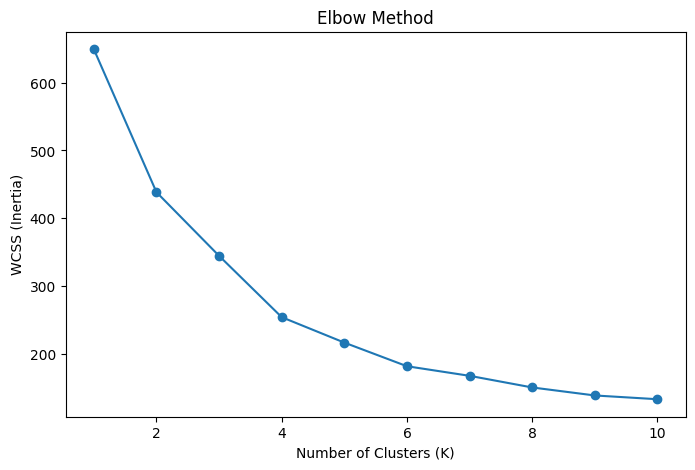

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(features_with_gender)

    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")

plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):   # Silhouette Score K=1 ke liye define nahi hota

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(features_with_gender)

    score = silhouette_score(features_with_gender, labels)
    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")


K = 2, Silhouette Score = 0.3032
K = 3, Silhouette Score = 0.3150
K = 4, Silhouette Score = 0.3503
K = 5, Silhouette Score = 0.3498
K = 6, Silhouette Score = 0.3565
K = 7, Silhouette Score = 0.3433
K = 8, Silhouette Score = 0.3304
K = 9, Silhouette Score = 0.3400
K = 10, Silhouette Score = 0.3087
